In [ ]:
!pip install torch torchvision transformers timm scikit-learn matplotlib seaborn Pillow tqdm gdown

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# DATA_ROOT = '/content/drive/MyDrive/Dataset/Compressed_Dataset'
DATA_ROOT = './Compressed_Dataset'   


In [ ]:
import os
print(f'Dataset path: {DATA_ROOT}')
if os.path.exists(DATA_ROOT):
    classes = [d for d in os.listdir(DATA_ROOT) if os.path.isdir(os.path.join(DATA_ROOT, d))]
    print(f'Found {len(classes)} classes: {classes}')
else:
    print('WARNING: Dataset path does not exist. Please update DATA_ROOT.')

Dataset path: /content/drive/MyDrive/Dataset/Compressed_Dataset
Found 8 classes: ['Powdery_Mildew', 'Leaf_Spot', 'Healthy', 'Anthracnose', 'Leaf_Blight', 'Black_Spot', 'Dry_Leaf', 'Abnormal']


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f'Using device: {DEVICE}')

In [ ]:
# Check and use Google Colab's cloud GPU/TPU (not your local CPU)
import torch

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'✅ Running on GPU: {torch.cuda.get_device_name(0)}')
    print(f'   Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    DEVICE = torch.device('cpu')
    print('⚠️ GPU not available — running on CPU.')
    print('   → Go to Runtime > Change runtime type > GPU to enable it. (Instructions to connect T4 GPU)')


✅ Running on GPU: Tesla T4
   Memory Available: 15.64 GB


In [ ]:
# --- lightweight configuration ------------------------------------------------
# Toggle this flag to train a much smaller model on a fraction of data so
# that training is feasible on a CPU-only machine. Set to False for the
# original full-size experiment (better accuracy, requires GPU/time).
LIGHTWEIGHT = True

if LIGHTWEIGHT:
    IMG_SIZE         = 128                # smaller input to reduce compute
    BATCH_SIZE       = 16                 # fewer images per batch
    NUM_EPOCHS       = 5                  # very short run
    MODEL_NAME       = 'vit_tiny_patch16_224'  # tiny ViT instead of base
    FREEZE_BACKBONE  = True               # only train classifier head
    SUBSET_FRACTION  = 0.25               # use 25% of each split
else:
    IMG_SIZE         = 224
    BATCH_SIZE       = 32
    NUM_EPOCHS       = 25
    MODEL_NAME       = 'vit_base_patch16_224'
    FREEZE_BACKBONE  = False
    SUBSET_FRACTION  = 1.0

print(f"Config - LIGHTWEIGHT={LIGHTWEIGHT}, IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, \
      EPOCHS={NUM_EPOCHS}, MODEL={MODEL_NAME}, FREEZE_BACKBONE={FREEZE_BACKBONE}, \
      SUBSET_FRAC={SUBSET_FRACTION}")


Config - LIGHTWEIGHT=True, IMG_SIZE=128, BATCH_SIZE=16,       EPOCHS=5, MODEL=vit_tiny_patch16_224, FREEZE_BACKBONE=True,       SUBSET_FRAC=0.25


### 4. Exploratory Data Analysis (EDA)

Class distribution:
  Abnormal: 562 images
  Anthracnose: 301 images
  Black_Spot: 759 images
  Dry_Leaf: 450 images
  Healthy: 506 images
  Leaf_Blight: 414 images
  Leaf_Spot: 595 images
  Powdery_Mildew: 480 images
  TOTAL: 4067 images


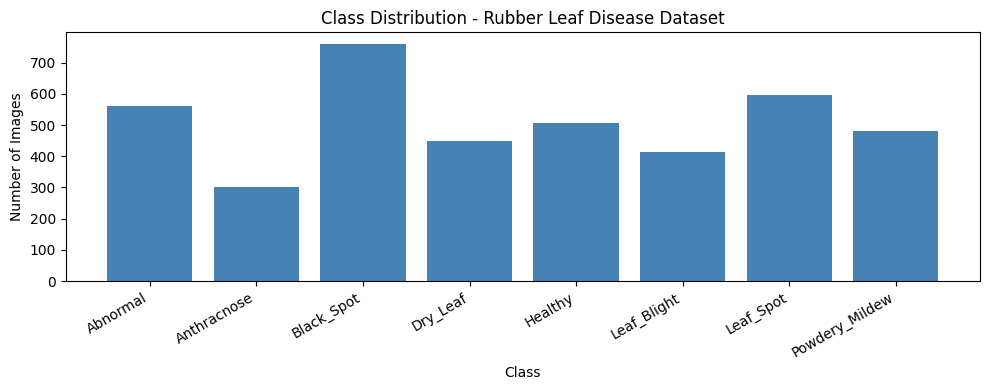

In [ ]:


# Count images per class
class_counts = {}
for cls in sorted(os.listdir(DATA_ROOT)):
    cls_path = os.path.join(DATA_ROOT, cls)
    if os.path.isdir(cls_path):
        imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        class_counts[cls] = len(imgs)

print('Class distribution:')
for cls, cnt in class_counts.items():
    print(f'  {cls}: {cnt} images')
print(f'  TOTAL: {sum(class_counts.values())} images')

# Bar chart
plt.figure(figsize=(10, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Class Distribution - Rubber Leaf Disease Dataset')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

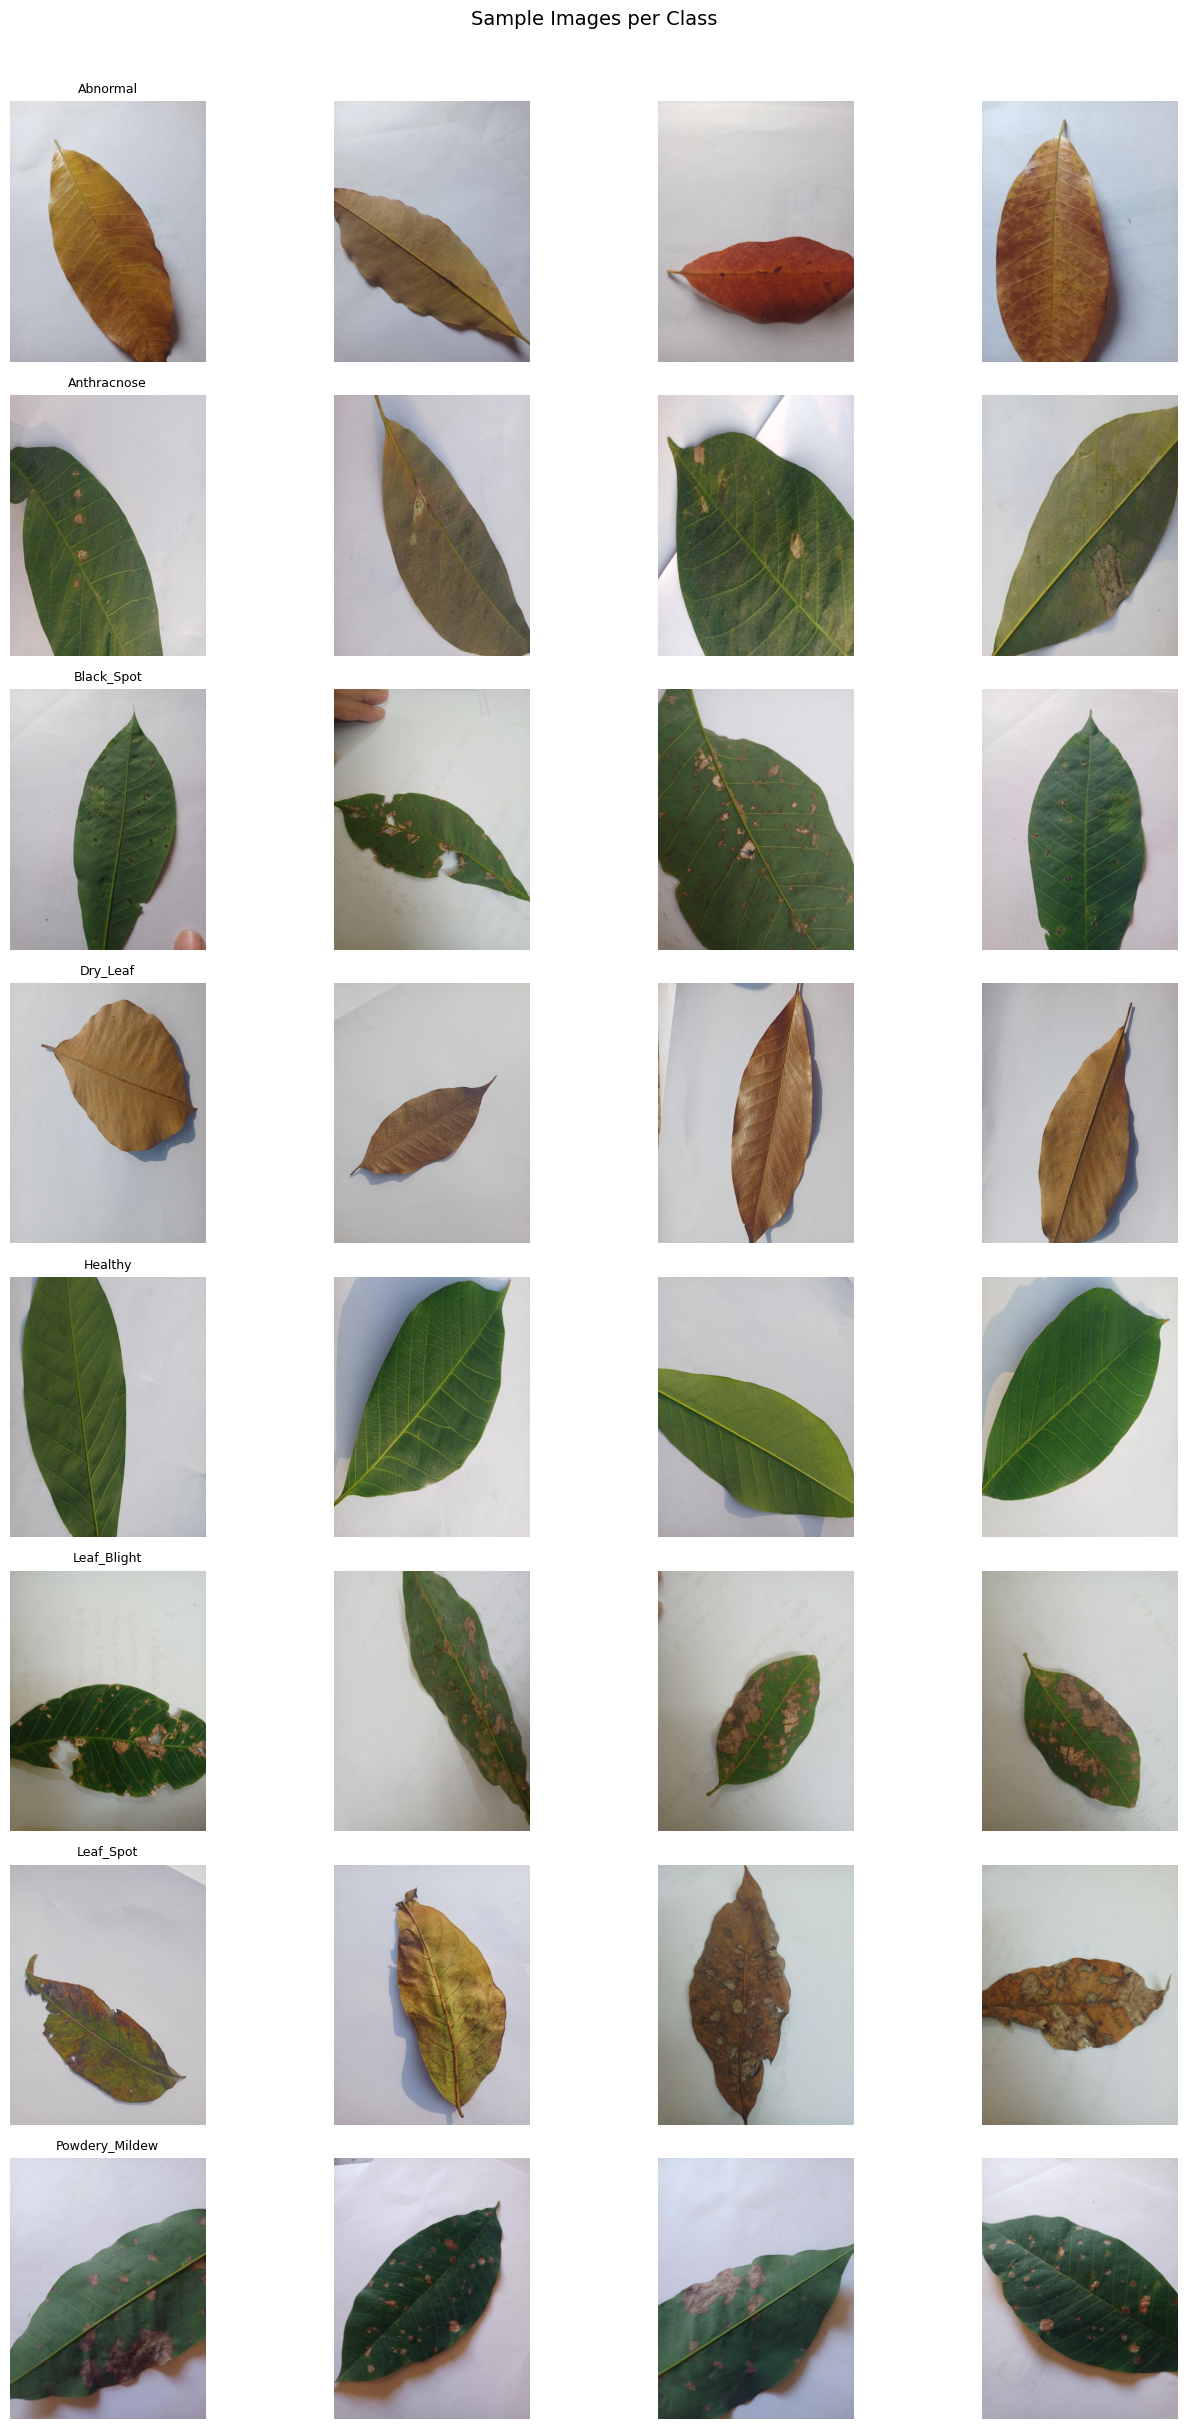

In [ ]:
# Visualize sample images from each class
classes = sorted(class_counts.keys())
fig, axes = plt.subplots(len(classes), 4, figsize=(14, 3 * len(classes)))
if len(classes) == 1:
    axes = [axes]

for i, cls in enumerate(classes):
    cls_path = os.path.join(DATA_ROOT, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    samples = random.sample(imgs, min(4, len(imgs)))
    for j, img_file in enumerate(samples):
        ax = axes[i][j] if len(classes) > 1 else axes[j]
        img = Image.open(os.path.join(cls_path, img_file)).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(cls if j == 0 else '', fontsize=9)

plt.suptitle('Sample Images per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Preprocessing & Data Augmentation

In [ ]:
# Respect lightweight/full configuration chosen earlier.
# If running this cell in isolation, fall back to standard ViT defaults.
if 'IMG_SIZE' not in globals():
    IMG_SIZE = 224
if 'BATCH_SIZE' not in globals():
    BATCH_SIZE = 32

# ImageNet mean/std (used for ViT pre-trained weights)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

print('Transforms defined.')

Transforms defined.


In [ ]:
# Load full dataset and split into train / val / test (70/15/15)
full_dataset = ImageFolder(root=DATA_ROOT)
CLASS_NAMES = full_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')

all_indices = list(range(len(full_dataset)))
all_labels  = [full_dataset.targets[i] for i in all_indices]

# Stratified split
train_idx, temp_idx = train_test_split(
    all_indices, test_size=0.30, stratify=all_labels, random_state=SEED)
temp_labels = [all_labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=temp_labels, random_state=SEED)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

Classes (8): ['Abnormal', 'Anthracnose', 'Black_Spot', 'Dry_Leaf', 'Healthy', 'Leaf_Blight', 'Leaf_Spot', 'Powdery_Mildew']
Train: 2846 | Val: 610 | Test: 611


In [ ]:
# Custom Subset Dataset to apply different transforms
class SubsetDataset(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        # img is already a PIL image from ImageFolder
        if self.transform:
            img = self.transform(img)
        return img, label

# Patch ImageFolder to return PIL images (not tensors)
full_dataset.transform = None   # remove transform so we get raw PIL

train_set = SubsetDataset(full_dataset, train_idx, train_transforms)
val_set   = SubsetDataset(full_dataset, val_idx,   val_transforms)
test_set  = SubsetDataset(full_dataset, test_idx,  val_transforms)

# Weighted sampler to handle class imbalance
train_labels = [all_labels[i] for i in train_idx]
class_sample_count = np.array([train_labels.count(c) for c in range(NUM_CLASSES)])
weight = 1.0 / class_sample_count
samples_weight = torch.tensor([weight[t] for t in train_labels], dtype=torch.float)
sampler = WeightedRandomSampler(samples_weight, num_samples=len(samples_weight), replacement=True)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)

print('DataLoaders ready.')

DataLoaders ready.


## 6. Build Vision Transformer (ViT) Model

In [ ]:
def build_vit_model(num_classes, pretrained=True, freeze_backbone=False):
    """
    Load ViT from timm with pre-trained ImageNet weights.
    Replace the classification head with one matching our num_classes.
    """
    model = timm.create_model(
        MODEL_NAME,
        pretrained=pretrained,
        num_classes=num_classes
    )

    if freeze_backbone:
        # Freeze all layers except the classification head
        for name, param in model.named_parameters():
            if 'head' not in name:
                param.requires_grad = False
        print('Backbone frozen. Only classifier head will be trained.')
    else:
        print('Full model will be fine-tuned.')

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total params    : {total_params:,}')
    print(f'Trainable params: {trainable_params:,}')
    return model

model = build_vit_model(num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=FREEZE_BACKBONE)
model = model.to(DEVICE)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Full model will be fine-tuned.
Total params    : 85,804,808
Trainable params: 85,804,808


## 7. Training Setup

In [ ]:
LR          = 3e-4
WEIGHT_DECAY = 1e-4

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)
criterion = nn.CrossEntropyLoss()

print(f'Optimizer : AdamW | LR={LR} | WeightDecay={WEIGHT_DECAY}')
print('Scheduler : CosineAnnealingLR')
print(f'Epochs    : {NUM_EPOCHS}')

Optimizer : AdamW | LR=0.0003 | WeightDecay=0.0001
Scheduler : CosineAnnealingLR
Epochs    : 25


## 8. Training Loop

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='  Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in tqdm(loader, desc='  Val  ', leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

In [ ]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

best_val_acc = 0.0
CHECKPOINT   = 'best_vit_rubber.pth'

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\nEpoch [{epoch}/{NUM_EPOCHS}]  LR={scheduler.get_last_lr()[0]:.2e}')

    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f'  Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f}')
    print(f'  Val   Loss: {vl_loss:.4f} | Val   Acc: {vl_acc:.4f}')

    # Save best model
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CHECKPOINT)
        print(f'  [✔] Best model saved (val_acc={best_val_acc:.4f})')

print(f'\nTraining complete. Best Val Acc: {best_val_acc:.4f}')


Epoch [1/25]  LR=3.00e-04


  Train Loss: 2.0110 | Train Acc: 0.2526
  Val   Loss: 1.5565 | Val   Acc: 0.4197
  [✔] Best model saved (val_acc=0.4197)

Epoch [2/25]  LR=2.99e-04


  Train Loss: 1.4250 | Train Acc: 0.5109
  Val   Loss: 1.2141 | Val   Acc: 0.6033
  [✔] Best model saved (val_acc=0.6033)

Epoch [3/25]  LR=2.95e-04


  Train Loss: 1.0400 | Train Acc: 0.7087
  Val   Loss: 0.8401 | Val   Acc: 0.7951
  [✔] Best model saved (val_acc=0.7951)

Epoch [4/25]  LR=2.90e-04


  Train Loss: 0.8608 | Train Acc: 0.8025
  Val   Loss: 0.8546 | Val   Acc: 0.7754

Epoch [5/25]  LR=2.82e-04


...

  Train Loss: 0.6095 | Train Acc: 0.9160
  Val   Loss: 0.6127 | Val   Acc: 0.8803

Epoch [22/25]  LR=1.95e-05


  Train Loss: 0.6004 | Train Acc: 0.9213
  Val   Loss: 0.6099 | Val   Acc: 0.8803

Epoch [23/25]  LR=1.15e-05


  Train Loss: 0.6034 | Train Acc: 0.9164
  Val   Loss: 0.6128 | Val   Acc: 0.8787

Epoch [24/25]  LR=5.70e-06


  Train Loss: 0.5991 | Train Acc: 0.9178
  Val   Loss: 0.6086 | Val   Acc: 0.8803

Epoch [25/25]  LR=2.18e-06


  Train Loss: 0.5934 | Train Acc: 0.9238
  Val   Loss: 0.6108 | Val   Acc: 0.8803

Training complete. Best Val Acc: 0.8803


## 9. Training Curves

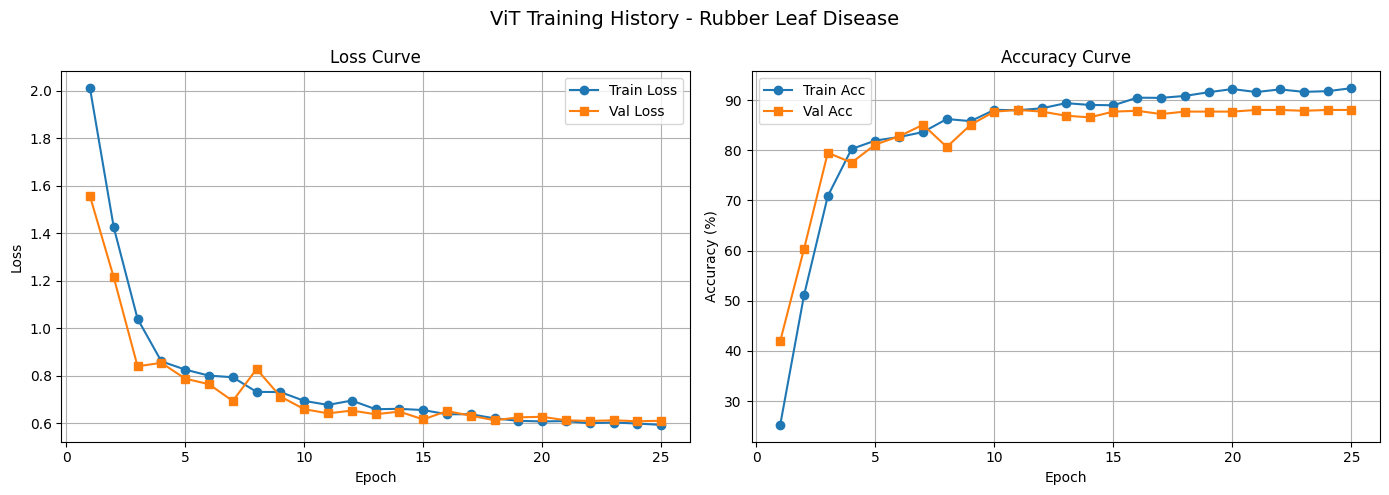

In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='s')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train Acc', marker='o')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val Acc',   marker='s')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('ViT Training History - Rubber Leaf Disease', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 10. Evaluation on Test Set

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))

test_loss, test_acc, test_preds, test_labels = eval_epoch(model, test_loader, criterion, DEVICE)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Acc : {test_acc:.4f} ({test_acc*100:.2f}%)')

Test Loss: 0.6190
Test Acc : 0.9018 (90.18%)


In [ ]:
# Classification Report
print('\nClassification Report:')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))


Classification Report:
                precision    recall  f1-score   support

      Abnormal       1.00      1.00      1.00        85
   Anthracnose       1.00      1.00      1.00        45
    Black_Spot       0.97      0.49      0.65       114
      Dry_Leaf       1.00      1.00      1.00        67
       Healthy       1.00      1.00      1.00        76
   Leaf_Blight       0.52      1.00      0.68        62
     Leaf_Spot       1.00      1.00      1.00        90
Powdery_Mildew       1.00      0.97      0.99        72

      accuracy                           0.90       611
     macro avg       0.94      0.93      0.91       611
  weighted avg       0.94      0.90      0.90       611



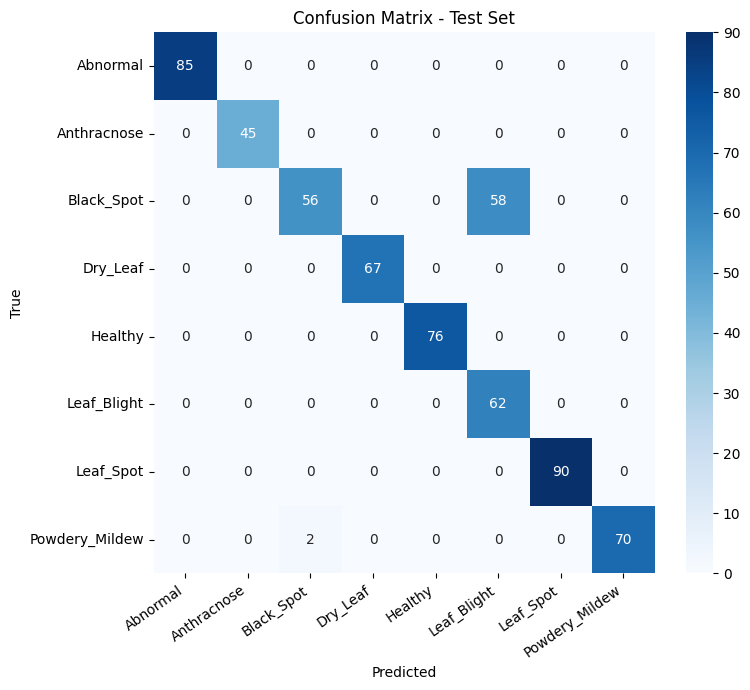

In [ ]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(max(6, NUM_CLASSES), max(5, NUM_CLASSES - 1)))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 11. Visualize Predictions on Sample Test Images

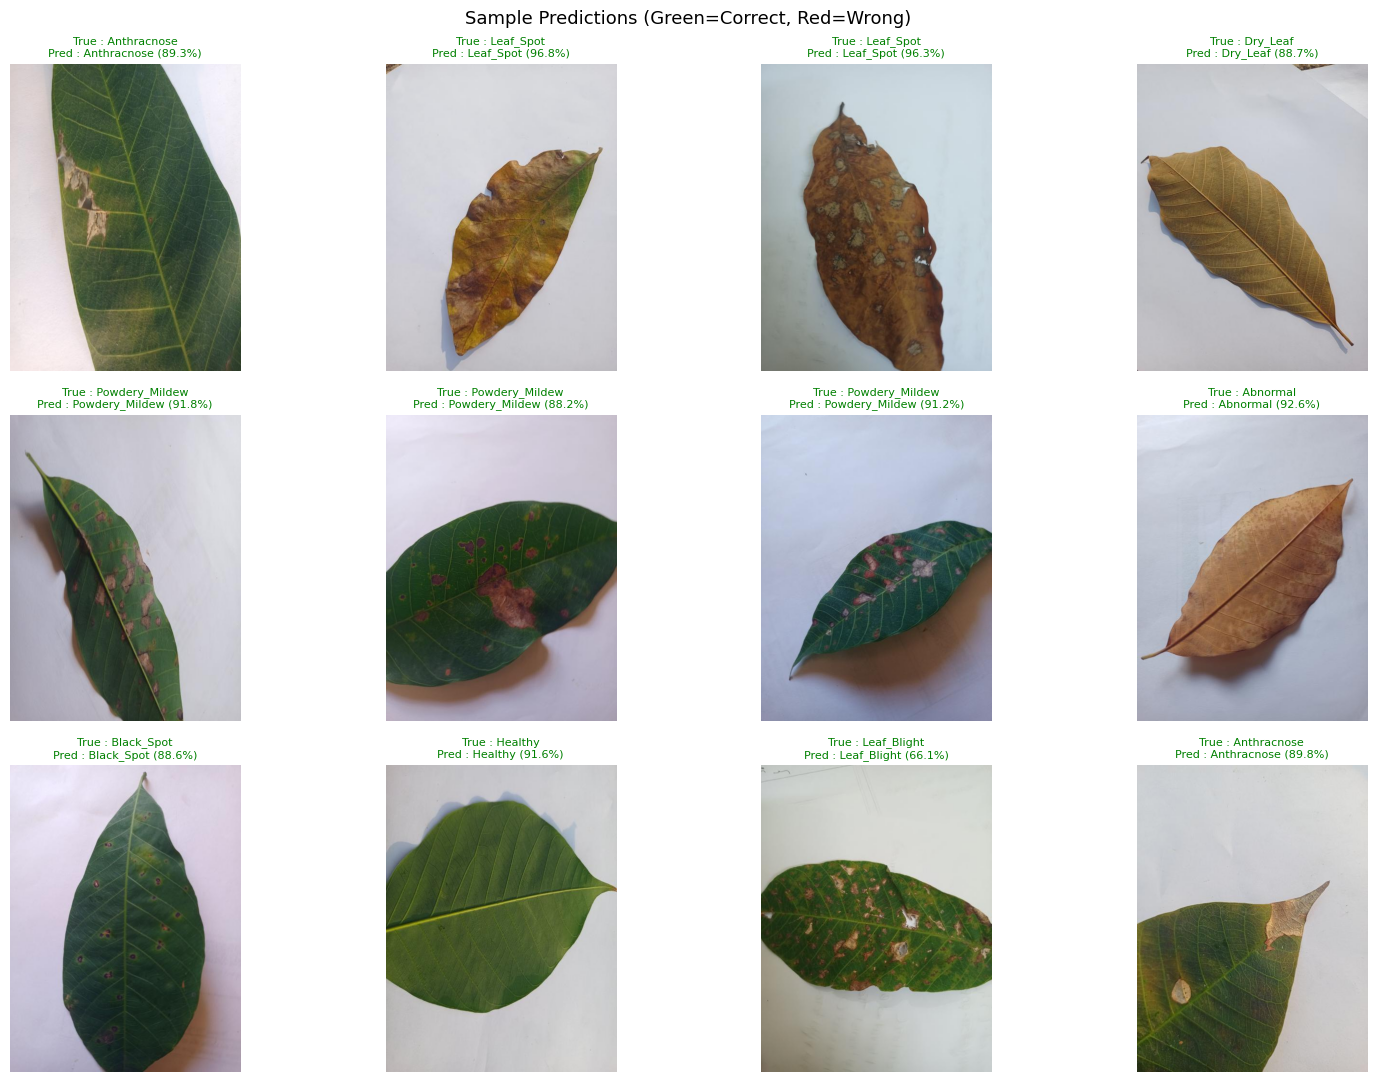

In [ ]:
@torch.no_grad()
def predict_single(model, pil_image, transform, device):
    img_tensor = transform(pil_image).unsqueeze(0).to(device)
    logits = model(img_tensor)
    probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred   = probs.argmax()
    return pred, probs

model.eval()
num_show = min(12, len(test_idx))
sample_indices = random.sample(test_idx, num_show)

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

for ax, idx in zip(axes, sample_indices):
    pil_img, true_label = full_dataset[idx]
    pred_label, probs = predict_single(model, pil_img, val_transforms, DEVICE)
    confidence = probs[pred_label] * 100

    ax.imshow(pil_img)
    ax.axis('off')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(
        f'True : {CLASS_NAMES[true_label]}\n'
        f'Pred : {CLASS_NAMES[pred_label]} ({confidence:.1f}%)',
        fontsize=8, color=color
    )

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

## 12. Save Final Model

In [ ]:
# Save full model state including metadata for robust later inference
torch.save({
    'model_state_dict'         : model.state_dict(),
    'class_names'              : CLASS_NAMES,
    'num_classes'              : NUM_CLASSES,
    'img_size'                 : IMG_SIZE,
    'model_name'               : MODEL_NAME,
    'checkpoint_format_version': 1,
    'best_val_acc'             : best_val_acc,
    'test_acc'                 : test_acc,
}, 'vit_rubber_leaf_final.pth')

print('Model saved as vit_rubber_leaf_final.pth')

Model saved as vit_rubber_leaf_final.pth


## 13. Inference on a New Image

In [ ]:
def load_model_for_inference(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    class_names = ckpt['class_names']
    num_classes = ckpt['num_classes']
    model_name = ckpt.get('model_name', 'vit_base_patch16_224')
    img_size = ckpt.get('img_size', 224)

    m = timm.create_model(model_name, pretrained=False, num_classes=num_classes)
    m.load_state_dict(ckpt['model_state_dict'])
    m.to(device).eval()
    return m, class_names, img_size


def classify_image(image_path, model, class_names, device, img_size):
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])
    img = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred = probs.argmax()
    print(f'Predicted: {class_names[pred]} ({probs[pred]*100:.2f}%)')
    for i, (cls, p) in enumerate(zip(class_names, probs)):
        print(f'  {cls}: {p*100:.2f}%')
    return class_names[pred], probs


# Example usage:
# inf_model, inf_classes, inf_img_size = load_model_for_inference('vit_rubber_leaf_final.pth', DEVICE)
# classify_image('path/to/your/leaf.jpg', inf_model, inf_classes, DEVICE, inf_img_size)
print('Inference helper functions ready.')

Inference helper functions ready.
